# 14장 (1단계) - 기본 멀티에이전트: content_strategist → communicator\n\n목차를 작성하는 `content_strategist`와 사용자에게 보고하는 `communicator`로 이어지는 단순 그래프.\n\n> `.env`에 `OPENAI_API_KEY`(OpenRouter)가 필요합니다. 노트북은 **chap14 폴더에서** 실행하세요.

In [7]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers.string import StrOutputParser
from typing_extensions import TypedDict
from typing import List, Union
from utils import save_state, get_outline, save_outline
from datetime import datetime
from dotenv import load_dotenv
import os

load_dotenv()

# 노트북은 __file__ 이 없으므로 현재 작업 폴더(chap14)를 기준 경로로 사용
current_path = os.getcwd()

# 모델 초기화 (OpenAI API 대신 OpenRouter 사용)
llm = ChatOpenAI(
    model="openai/gpt-4o",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv('OPENAI_API_KEY'),
)

In [8]:
# 상태 정의
class State(TypedDict):
    messages: List[Union[AnyMessage, str]]

In [9]:
# 목차를 작성하는 노드(agent)
def content_strategist(state: State):
    print("\n\n============ CONTENT STRATEGIST ============")

    content_strategist_system_prompt = PromptTemplate.from_template(
        """
        너는 책을 쓰는 AI팀의 콘텐츠 전략가(Content Strategist)로서,
        이전 대화 내용을 바탕으로 사용자의 요구사항을 분석하고, AI팀이 쓸 책의 세부 목차를 결정한다.

        지난 목차가 있다면 그 버전을 사용자의 요구에 맞게 수정하고, 없다면 새로운 목차를 제안한다.

        --------------------------------
        - 지난 목차: {outline}
        --------------------------------
        - 이전 대화 내용: {messages}
        """
    )

    content_strategist_chain = content_strategist_system_prompt | llm | StrOutputParser()

    messages = state["messages"]
    outline = get_outline(current_path)

    inputs = {
        "messages": messages,
        "outline": outline,
    }

    # 목차 작성 (스트림으로 출력하면서 gathered에 모으기)
    gathered = ''
    for chunk in content_strategist_chain.stream(inputs):
        gathered += chunk
        print(chunk, end='')

    print()

    save_outline(current_path, gathered)      # 목차 저장

    content_strategist_message = "[Content Strategist] 목차 작성 완료"
    print(content_strategist_message)
    messages.append(AIMessage(content_strategist_message))

    return {"messages": messages}

In [10]:
# 사용자와 대화할 노드(agent): communicator
def communicator(state: State):
    print("\n\n============ COMMUNICATOR ============")

    communicator_system_prompt = PromptTemplate.from_template(
        """
        너는 책을 쓰는 AI팀의 커뮤니케이터로서,
        AI팀의 진행상황을 사용자에게 보고하고, 사용자의 의견을 파악하기 위한 대화를 나눈다.

        사용자도 outline(목차)을 이미 보고 있으므로, 다시 출력할 필요는 없다.
        outline: {outline}
        --------------------------------
        messages: {messages}
        """
    )

    system_chain = communicator_system_prompt | llm

    messages = state["messages"]

    inputs = {
        "messages": messages,
        "outline": get_outline(current_path),
    }

    gathered = None

    print('\nAI\t: ', end='')
    for chunk in system_chain.stream(inputs):
        print(chunk.content, end='')

        if gathered is None:
            gathered = chunk
        else:
            gathered += chunk

    messages.append(gathered)

    return {"messages": messages}

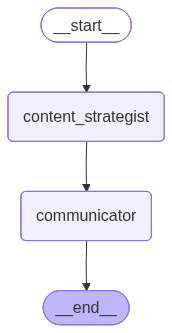

In [11]:
from IPython.display import Image, display

# 상태 그래프 정의
graph_builder = StateGraph(State)

# Nodes
graph_builder.add_node("content_strategist", content_strategist)
graph_builder.add_node("communicator", communicator)

# Edges
graph_builder.add_edge(START, "content_strategist")
graph_builder.add_edge("content_strategist", "communicator")
graph_builder.add_edge("communicator", END)

graph = graph_builder.compile()

# 그래프 도식화 (노트북에서는 인라인으로 표시)
display(Image(graph.get_graph().draw_mermaid_png()))

## 실행\n아래 셀을 실행하면 입력창이 나타납니다. `HYBE와 JYP 경영 전략을 비교하는 책을 써줘` 처럼 입력하고, `q`로 종료하세요.

In [15]:
# 상태 초기화
state = State(
    messages=[
        SystemMessage(
            f"""
            너희 AI들은 사용자의 요구에 맞는 책을 쓰는 작가팀이다.
            사용자가 사용하는 언어로 대화하라.

            현재시각은 {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}이다.
            """
        )
    ],
)

# 아래 셀을 실행하면 입력창이 나타난다. 책 주제를 입력하고, exit / quit / q 로 종료한다.
while True:
    user_input = input("\nUser\t: ").strip()

    if user_input.lower() in ['exit', 'quit', 'q']:
        print("Goodbye!")
        break

    state["messages"].append(HumanMessage(user_input))
    state = graph.invoke(state)

    print('\n----------------------------------- MESSAGE COUNT\t', len(state["messages"]))

    save_state(current_path, state)



============ CONTENT STRATEGIST ============
안녕하세요! 책의 세부 목차를 작성하기 위해 사용자 요구에 대한 정보를 바탕으로 몇 가지 주제를 제안하겠습니다. 

이 책의 주제가 무엇인지, 어떤 내용을 담고 싶은지, 대상 독자가 누구인지 등의 추가적인 정보가 있으면 더 정교한 목차를 만들 수 있겠지만, 우선 일반적인 구조의 목차를 제안하겠습니다.

### 제안하는 책의 세부 목차

#### 1. 서론
   - 책의 목적
   - 독자에게 기대하는 것
   - 사용 방법 안내

#### 2. AI의 기본 개념
   - AI란 무엇인가?
   - AI의 역사와 발전 과정
   - AI의 다양한 유형

#### 3. AI의 적용 사례
   - 산업별 AI 활용 사례
     - 제조업
     - 헬스케어
     - 금융
   - 일상에서의 AI

#### 4. AI 기술의 심화
   - 머신러닝과 딥러닝의 원리
   - 자연어 처리(NLP)와 그 응용
   - 컴퓨터 비전의 발전

#### 5. AI의 윤리와 사회적 영향
   - AI의 윤리적 쟁점
   - 데이터 프라이버시와 보안
   - AI가 사회에 미치는 영향

#### 6. AI의 미래 전망
   - 향후 기술 발전 방향
   - 일자리와 경제
   - AI와 인간의 공존

#### 7. 결론
   - 주요 요점 요약
   - 독자에게 전하고 싶은 메시지

#### 8. 참고 문헌
   - 관련 자료 및 추천 도서 리스트

위 목차는 기본적인 구조를 포함하고 있으며, 원하는 내용이나 추가하고 싶은 특정 주제가 있다면 편하게 말씀해 주세요. 이를 기반으로 목차를 수정하거나 보완할 수 있습니다.
[Content Strategist] 목차 작성 완료


============ COMMUNICATOR ============

AI	: 안녕하세요! 책의 세부 목차에 대한 피드백을 주실 수 있으신가요? 혹시 특정 주제를 추가하거나 수정하고 싶은 부분이 있다면 말씀해 주세요. 

KeyboardInterrupt: Interrupted by user